In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv('clean_master.csv')
print('Shape:', df.shape)
print('Churn Rate:', round(df['churn'].mean() * 100, 2), '%')

Shape: (6001, 19)
Churn Rate: 37.51 %


## Model Design Decision - Two Separate Outputs

Churn was defined as 'zero transactions in 90 days prior to 30 Sept 2024.'
Including transaction-derived features (recency, frequency, amount) creates
circular reasoning - the model rediscovers its own label definition rather
than learning genuine predictive patterns.

Therefore this project produces **two separate outputs:**

- **Model 1 - Behavioral Trigger Classifier** (transaction features included)
  - Identifies already-churning customers for immediate intervention
  - Uses: total_transactions, total_transaction_amount, support tickets
  - Limitation: confirms existing behavior, does not predict future churn

- **Model 2 - Early Warning Demographic Model** (no transaction features)
  - Trained on upstream signals only: KYC, credit saturation, income, age
  - Used for proactive onboarding intervention before behavior drops off

- **Behavioral Trigger Rule (SQL-based)**
  - Simplest and strongest retention tool
  - Any customer with zero transactions in 30 days triggers automated alert

In [23]:
# ================================================================
# MODEL 1 — Behavioral Trigger Classifier
# Uses transaction features to identify already-churning customers
# days_since_last_transaction excluded — too directly tied to label
# ================================================================

COLS_TO_DROP_M1 = [
    'customer_id', 'signup_date', 'last_transaction_date',
    'churn_probability', 'annual_revenue',
    'days_since_last_transaction'  # excluded — direct label proxy
]

df_ml = df.drop(columns=COLS_TO_DROP_M1, errors='ignore')

cat_cols = ['city', 'acquisition_channel', 'employment_type', 'kyc_status', 'primary_product']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml = df_ml.select_dtypes(include=['number'])

X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for col in X_train.columns:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

print('Model 1 Features (Behavioral Trigger):')
print(X_train.columns.tolist())
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Model 1 Features (Behavioral Trigger):
['age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'total_tickets', 'high_risk_tickets']
Training size: (4800, 12)
Testing size: (1201, 12)


In [24]:
# Model 1 — Logistic Regression (Baseline)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print('=== Logistic Regression — Model 1 (Behavioral Trigger) ===')
print(classification_report(y_test, lr_pred))
print(f'ROC-AUC Score: {lr_auc:.4f}')

=== Logistic Regression — Model 1 (Behavioral Trigger) ===
              precision    recall  f1-score   support

           0       0.71      0.85      0.78       740
           1       0.65      0.44      0.53       461

    accuracy                           0.70      1201
   macro avg       0.68      0.65      0.65      1201
weighted avg       0.69      0.70      0.68      1201

ROC-AUC Score: 0.6875


In [25]:
# Model 1 — Random Forest (Final)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print('=== Random Forest — Model 1 (Behavioral Trigger) ===')
print(classification_report(y_test, rf_pred))
print(f'ROC-AUC Score: {rf_auc:.4f}')

=== Random Forest — Model 1 (Behavioral Trigger) ===
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       740
           1       0.61      0.39      0.48       461

    accuracy                           0.67      1201
   macro avg       0.65      0.62      0.62      1201
weighted avg       0.66      0.67      0.65      1201

ROC-AUC Score: 0.6753


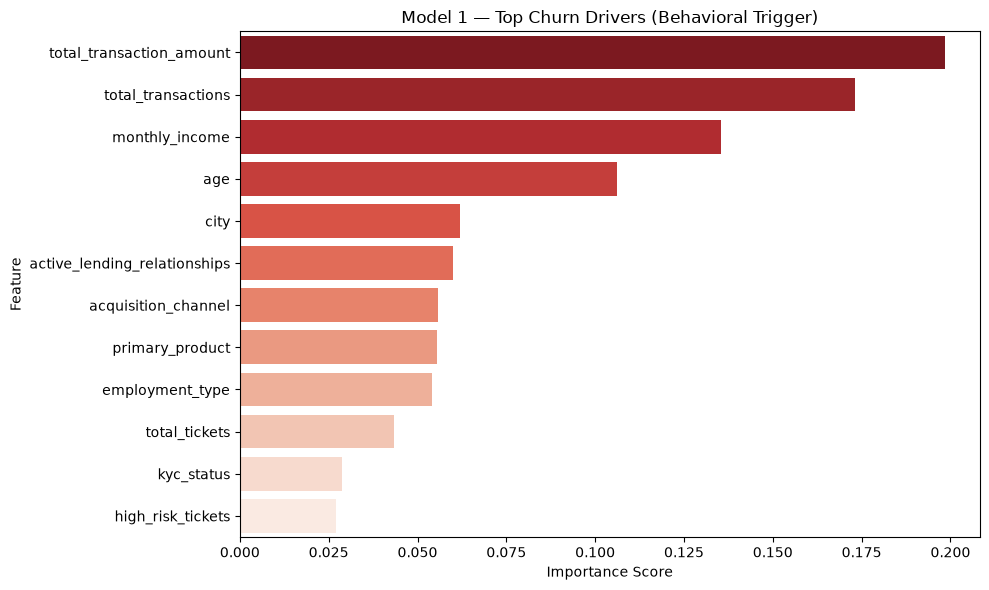

In [26]:
# Model 1 — Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='Reds_r')
plt.title('Model 1 — Top Churn Drivers (Behavioral Trigger)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150)
plt.show()

In [27]:
# ================================================================
# MODEL 2 — Early Warning Demographic Model
# NO transaction features — predicts risk from upstream signals
# ================================================================

COLS_TO_DROP_M2 = [
    'customer_id', 'signup_date', 'last_transaction_date',
    'churn_probability', 'annual_revenue',
    'days_since_last_transaction',
    'total_transactions',
    'total_transaction_amount'
]

df_ml2 = df.drop(columns=COLS_TO_DROP_M2, errors='ignore')

cat_cols = ['city', 'acquisition_channel', 'employment_type', 'kyc_status', 'primary_product']
le2 = LabelEncoder()
for col in cat_cols:
    df_ml2[col] = le2.fit_transform(df_ml2[col].astype(str))

df_ml2 = df_ml2.select_dtypes(include=['number'])

X2 = df_ml2.drop(columns=['churn'])
y2 = df_ml2['churn']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

for col in X2_train.columns:
    med = X2_train[col].median()
    X2_train[col] = X2_train[col].fillna(med)
    X2_test[col] = X2_test[col].fillna(med)

print('Model 2 Features (Early Warning — Demographic Only):')
print(X2_train.columns.tolist())
print('NaNs remaining:', X2_train.isnull().sum().sum())

Model 2 Features (Early Warning — Demographic Only):
['age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_tickets', 'high_risk_tickets']
NaNs remaining: 0


In [28]:
# Model 2 — Random Forest
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X2_train, y2_train)
rf_pred2 = rf_model2.predict(X2_test)
rf_auc2 = roc_auc_score(y2_test, rf_model2.predict_proba(X2_test)[:,1])

print('=== Random Forest — Model 2 (Early Warning Demographic) ===')
print(classification_report(y2_test, rf_pred2))
print(f'ROC-AUC Score: {rf_auc2:.4f}')
print()
print('Interpretation: Lower AUC confirms demographic signals alone')
print('cannot predict behavioral churn — validating the two-model approach.')
print('This model is used for PROACTIVE risk segmentation, not churn detection.')

=== Random Forest — Model 2 (Early Warning Demographic) ===
              precision    recall  f1-score   support

           0       0.62      0.86      0.72       740
           1       0.41      0.16      0.23       461

    accuracy                           0.59      1201
   macro avg       0.51      0.51      0.47      1201
weighted avg       0.54      0.59      0.53      1201

ROC-AUC Score: 0.5114

Interpretation: Lower AUC confirms demographic signals alone
cannot predict behavioral churn — validating the two-model approach.
This model is used for PROACTIVE risk segmentation, not churn detection.


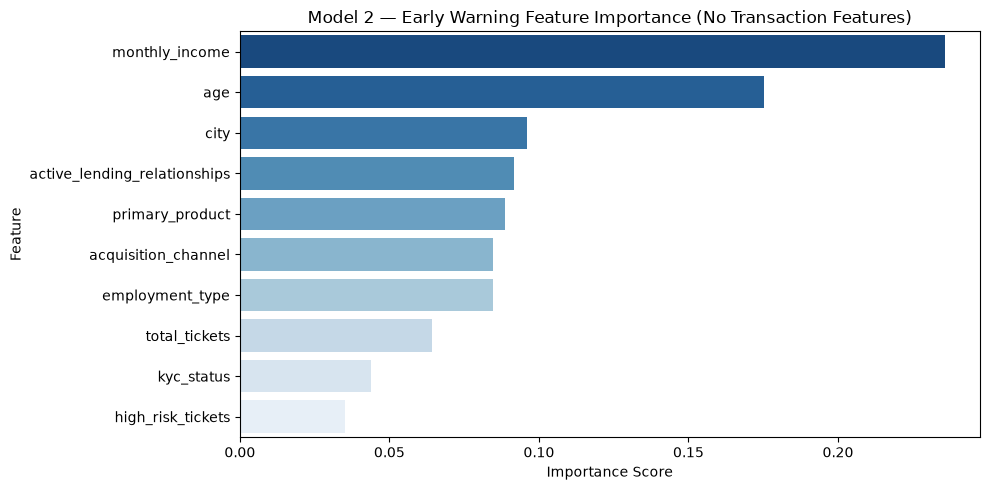

Top demographic churn driver: monthly_income


In [29]:
# Model 2 — Feature Importance
feature_importance2 = pd.DataFrame({
    'feature': X2_train.columns,
    'importance': rf_model2.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feature_importance2, palette='Blues_r')
plt.title('Model 2 — Early Warning Feature Importance (No Transaction Features)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/feature_importance_early_warning.png', dpi=150)
plt.show()

print('Top demographic churn driver:', feature_importance2.iloc[0]['feature'])

In [30]:
# Model Comparison Summary
print('=' * 60)
print('          MODEL COMPARISON SUMMARY')
print('=' * 60)
print(f'Model 1 — Behavioral Trigger (LR)  : AUC = {lr_auc:.4f}')
print(f'Model 1 — Behavioral Trigger (RF)  : AUC = {rf_auc:.4f}')
print(f'Model 2 — Early Warning Demo (RF)  : AUC = {rf_auc2:.4f}')
print()
print('Model 1 Purpose : Identify already-churning customers')
print('Model 2 Purpose : Segment high-risk customers before churn')
print('SQL Rule Purpose: Flag zero-transaction customers in real-time')
print('=' * 60)

          MODEL COMPARISON SUMMARY
Model 1 — Behavioral Trigger (LR)  : AUC = 0.6875
Model 1 — Behavioral Trigger (RF)  : AUC = 0.6753
Model 2 — Early Warning Demo (RF)  : AUC = 0.5114

Model 1 Purpose : Identify already-churning customers
Model 2 Purpose : Segment high-risk customers before churn
SQL Rule Purpose: Flag zero-transaction customers in real-time
